In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import math
import scipy.stats
import warnings
from scipy.stats import norm
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format

import pmdarima as pm
import arch
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.stl import STLForecast

# 데이터 불러오기
original = pd.read_csv('c:\python\data2(filtered).csv', dtype={2: 'str'}).iloc[:,2:7]

original = original.reset_index(drop = True)
# 신고중량이 0으로 신고된 수입건 제외
original = original.drop(original[original['신고중량'] == 0].index)
# 1년간 수입한 일수가 100일 미만은 품목 제외
#year_ago = original['수리일자'].max() - 10000
#hs_hole = list(original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts()[original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts() < 100].index)
#original = original[~original['HS10단위부호'].isin(hs_hole)]

# 연도_주차 구하기
original['수리일자'] = original['수리일자'].astype(str)
original['수리일자'] = pd.to_datetime(original['수리일자'])
original['연도'] = original['수리일자'].dt.year
original['월'] = original['수리일자'].dt.month
original['주차'] = original['수리일자'].dt.isocalendar().week
original['연도주차'] = original['연도'] * 100 + original['주차']
original['연도주차'][(original['월'] == 1) & (original['주차'] > 5)] -= 100
original['연도주차'][(original['월'] == 12) & (original['주차'] < 5)] += 100
original['연도주차'] = original['연도주차'].apply(lambda x : str(x)[2:4] + '_' + str(x)[4:])

# 전체 연도_주차 데이터 생성
date_index = original['연도주차'].unique()
# 사용하는 컬럼 정리
use_col = ['HS10단위부호', '연도주차', '무역거래처국가코드', '신고중량', '과세가격미화금액']

p_eriod = -52


HS Code : 3102109000
      연도주차    단가         신고중량
0    17_04 0.255  5332959.546
1    17_05 0.262  6013912.829
2    17_06 0.266  5785572.955
3    17_07 0.274  6293268.930
4    17_08 0.273  5994605.184
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
21_40주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-360.968, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-356.828, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-361.682, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-362.616, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-341.734, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-361.052, Time=0.09 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-359.744, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-357.381, Time=0

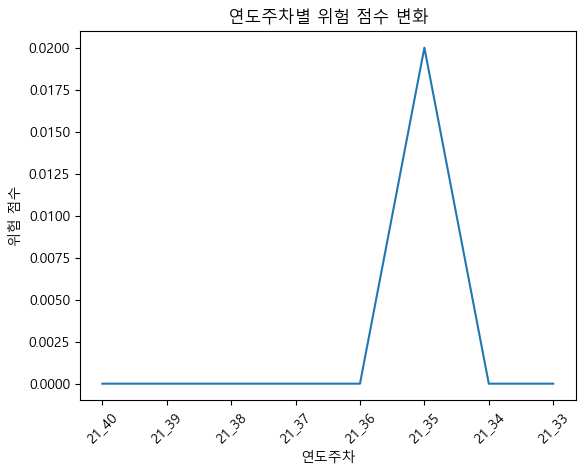

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_04 219.044 17693.709
1    17_05 213.153 21010.400
2    17_06 216.113 19536.734
3    17_07 227.025 18619.221
4    17_08 223.977 18453.471
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
19_30주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=472.137, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=718.492, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=471.549, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=470.310, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=473.669, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] 

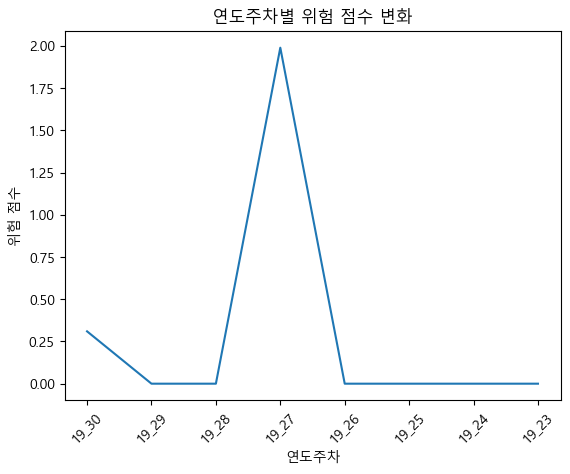

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_04 1.321 239293.247
1    17_05 1.320 250460.747
2    17_06 1.335 267243.948
3    17_07 1.353 205743.000
4    17_08 1.355 166353.875
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
21_14주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-186.402, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-183.770, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-181.797, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-181.796, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-185.614, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-184.307, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-177.809, Time=0.04 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(2,1,3)(0,0,0)[

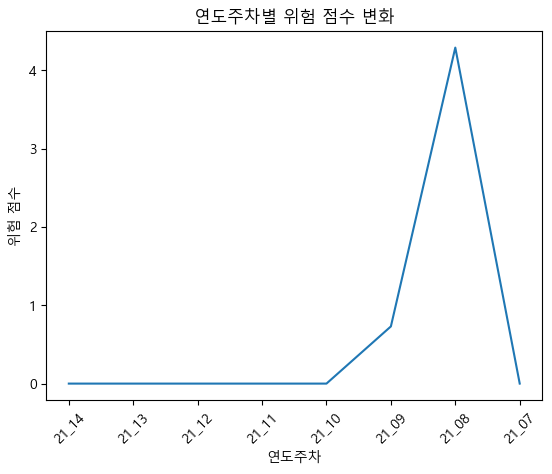

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_04 2.294 1589538.823
1    17_05 2.322 1797062.025
2    17_06 2.349 2135029.125
3    17_07 2.255 2589847.688
4    17_08 2.222 2647460.135
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
21_45주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-126.195, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-97.980, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-129.887, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-115.490, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-79.527, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-128.177, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-128.088, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-127.190, Time=0.07 sec
 ARIMA

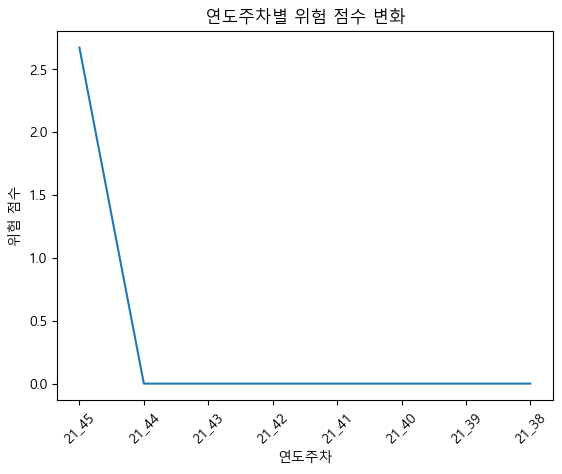

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_04 0.177 163414532.500
1    17_05 0.183 128339537.000
2    17_06 0.187  77542167.000
3    17_07 0.178  87019096.075
4    17_08 0.165 107989167.275
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
21_51주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-322.997, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-325.959, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-324.300, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-324.375, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-320.721, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.268 seconds
====================== Statemodels를 활용한 

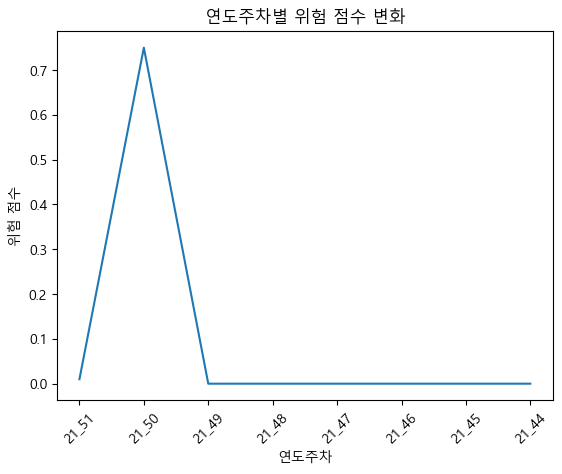

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_04 2.811 160032.550
1    17_05 2.856 164322.550
2    17_06 2.862 142277.500
3    17_07 2.849 143690.000
4    17_08 2.827 128430.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
21_51주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-23.189, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-19.592, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-26.111, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-24.772, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-18.717, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-24.497, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-24.412, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-22.498, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] 

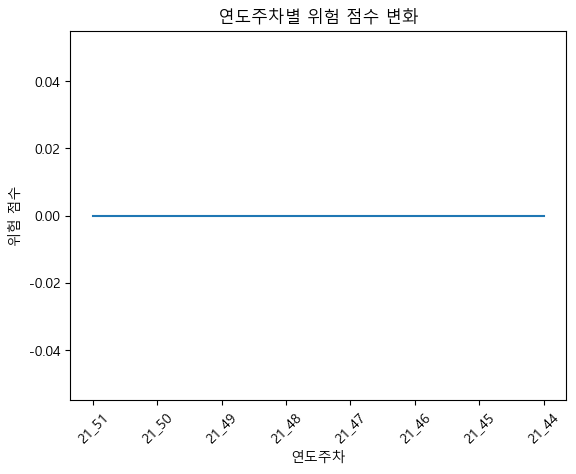

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_04 0.735  936849.355
1    17_05 0.734  930738.055
2    17_06 0.754  893311.305
3    17_07 0.756 1637404.305
4    17_08 0.774 1212247.700
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
22_02주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-217.251, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-215.618, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-215.631, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-214.233, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-213.627, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.191 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence le

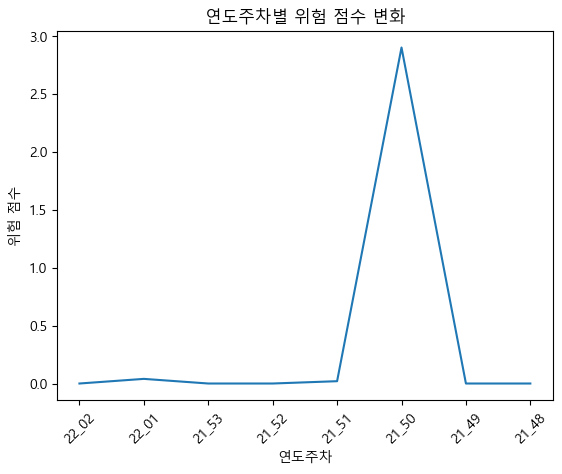

HS Code : 305531000
      연도주차     단가       신고중량
0    17_04 10.143 112739.000
1    17_05 10.020 106671.250
2    17_06  9.953 107973.500
3    17_07  9.665  98612.500
4    17_08  9.570  93437.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
22_07주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=17.161, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=17.693, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=17.248, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=15.362, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.379 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ===

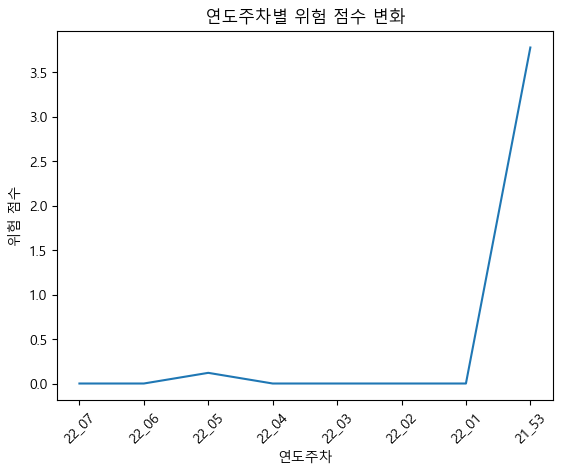

HS Code : 302140000
      연도주차     단가       신고중량
0    17_04 12.297 248997.765
1    17_05 11.776 247770.110
2    17_06 11.204 258943.758
3    17_07 10.781 262438.498
4    17_08 10.400 279016.205
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
22_08주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=388.599, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-22.355, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-37.707, Time=0.11 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,0,3)(0,0,0)[0]          

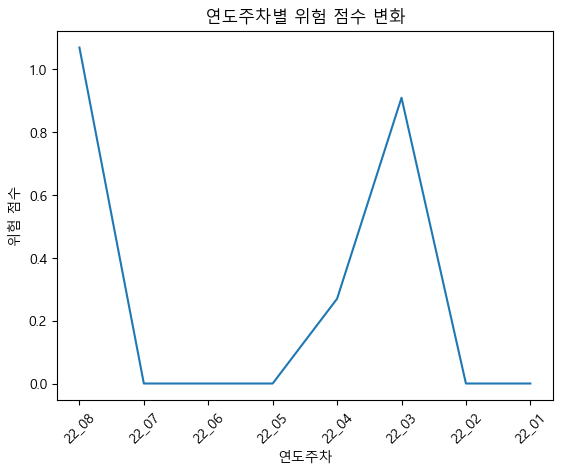

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_04   NaN         NaN
1    17_05   NaN         NaN
2    17_06   NaN         NaN
3    17_07   NaN         NaN
4    17_08 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: True
22_07주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-374.064, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-376.945, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-379.382, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-379.986, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-378.835, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-377.840, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-376.670, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-376.003, Time=0.12 sec
 ARIM

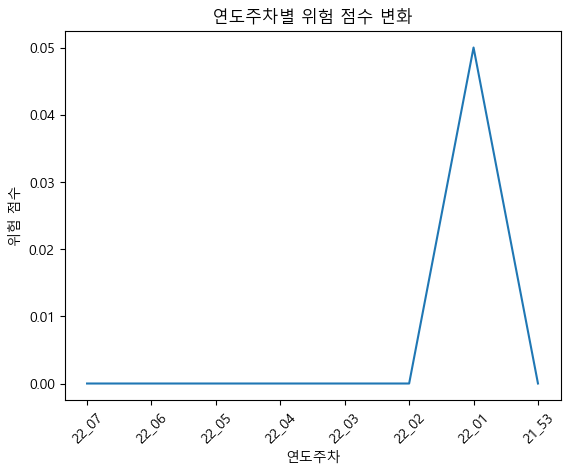

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_04 0.192 3149912.500
1    17_05 0.192 3412412.500
2    17_06 0.192 2054420.000
3    17_07 0.192 1861815.000
4    17_08 0.192  354402.500
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
22_07주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-313.686, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-321.494, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-319.497, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-319.497, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-321.133, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-317.631, Time=0.04 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.200 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confiden

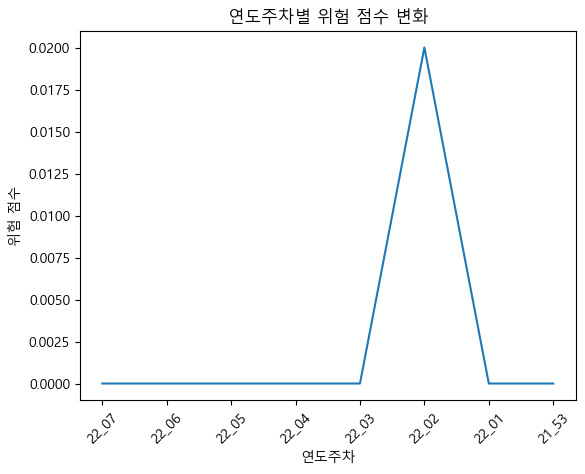

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_04 0.389  38475.125
1    17_05 0.430 166375.125
2    17_06 0.477 415325.600
3    17_07 0.478 462700.475
4    17_08 0.475 537900.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
22_07주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-383.923, Time=0.14 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=55.140, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-398.307, Time=0.10 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-66.722, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-393.287, Time=0.08 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,3)(0,0,0)[0]           

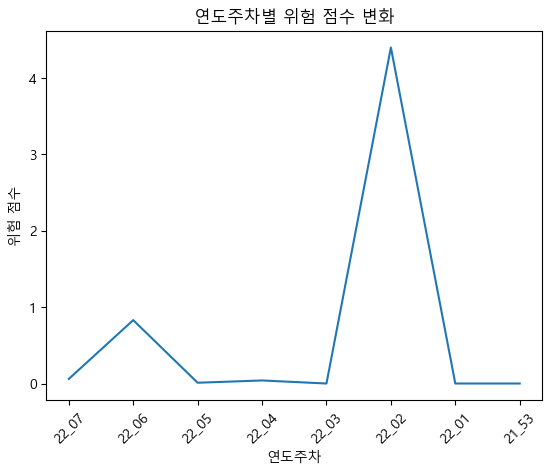

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_04 0.551  2149886.250
1    17_05 0.550  4114309.500
2    17_06 0.549  6381111.750
3    17_07 0.549  4234150.250
4    17_08 0.547  9687853.750
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
22_07주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-146.821, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-149.901, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-149.137, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-149.182, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-151.403, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-147.182, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.357 seconds
====================== Statemodels를 활용한 ARIMA 예

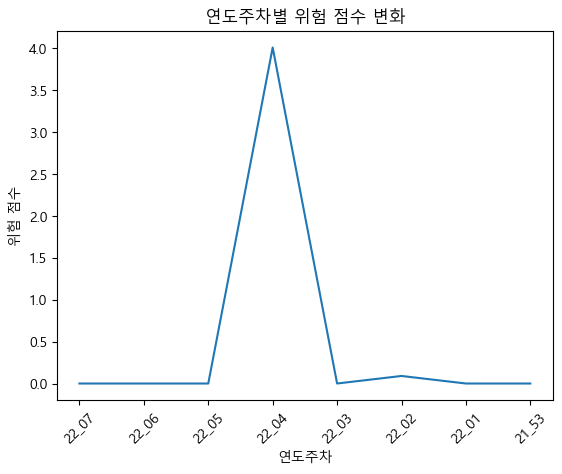

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_04 0.299 11374102.375
1    17_05 0.298 16317880.400
2    17_06 0.291 12415604.100
3    17_07 0.291 10819745.700
4    17_08 0.289 11582318.950
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
22_07주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-162.710, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-161.249, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-161.251, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-162.609, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-159.223, Time=0.07 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.398 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 c

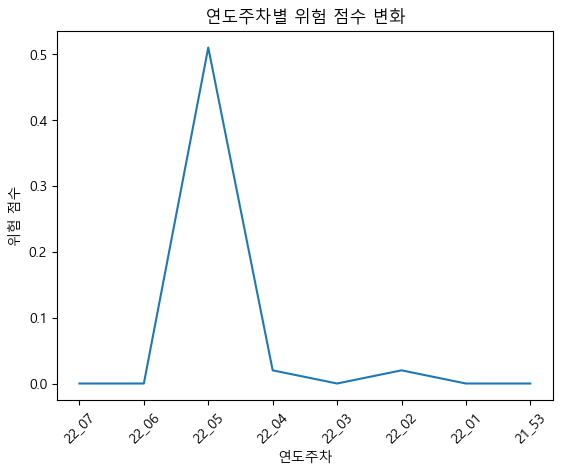

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_04 1.801  49211.300
1    17_05 1.754  65983.925
2    17_06 1.838  79977.625
3    17_07 1.857  61760.131
4    17_08 1.863  63759.256
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]
NaN 또는 0 값 포함 여부: False
22_16주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-97.064, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-95.065, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-95.065, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-96.503, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-93.065, Time=0.04 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.394 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ======

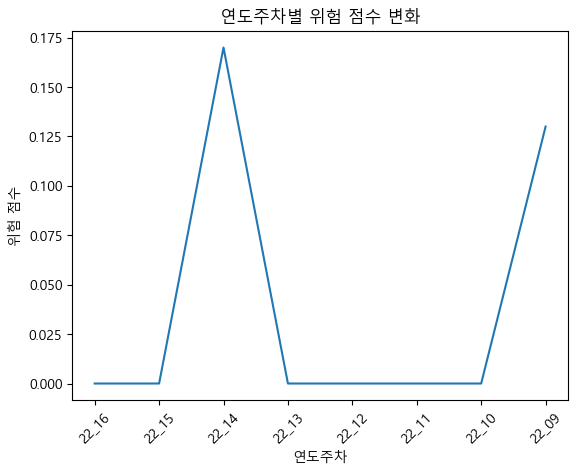

[np.float64(0.02), np.float64(1.99), np.float64(4.29), np.float64(2.67), np.float64(0.75), 0, np.float64(2.9), np.float64(3.78), np.float64(1.07), np.float64(0.05), np.float64(0.02), np.float64(4.4), np.float64(4.01), np.float64(0.51), np.float64(0.17)]
[56, 169, 83, 46, 41, 0, 41, 38, 30, 37, 36, 36, 34, 33, 24]


In [2]:
추출용 = [3102109000,3707901010,4407191000,8111000000,2701129010,2804701000,1511901000,305531000,302140000,1003901000,1003902000,1104230000,2710121000,3104200000,2905172000]
b = [59, 174, 85, 54, 48, 48, 44, 39, 38, 39, 39, 39, 39, 39, 30]

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    print(df_price_4w)
    
    contains_nan_or_zero = df_price_4w.isna().any().any() or (df_price_4w == 0).any().any()
    print(f"NaN 또는 0 값 포함 여부: {contains_nan_or_zero}")

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        res_resid = df_price_4w['단가'].iloc[p_eriod-l:-l]
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]
        model = pm.auto_arima(res_resid[:-n_test], seasonal=False, trace=True)
        model_fit = model.fit(res_resid[:-n_test])
        p, d, q = model.order

        print('====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============')
        model1 = ARIMA(res_resid[:-n_test], order=(p,d,q))
        model_fit1 = model1.fit()
        forecast1 = model_fit1.get_forecast(steps=1)
              
        print('======================= 여기부터 GARCH 모델링 =================================')
        arima_residuals = model_fit1.resid
        garch = arch.arch_model(arima_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        # Use GARCH to predict the residual
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        
        stand_quant = (test.iloc[0] - forecast1.predicted_mean.iloc[0])/ garch_std
        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)

      #=================== 신고중량 ======================
        res_resid = df_price_4w['신고중량'].iloc[p_eriod-l:-l]
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]

        model = pm.auto_arima(res_resid[:-n_test], seasonal=False, trace=True)
        model_fit = model.fit(res_resid[:-n_test])
        p, d, q = model.order

        print('====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============')
        model1 = ARIMA(res_resid[:-n_test], order=(p,d,q))
        model_fit1 = model1.fit()
        forecast1 = model_fit1.get_forecast(steps=1)

        print('======================= 여기부터 GARCH 모델링 =================================')
        arima_residuals = model_fit1.resid
        garch = arch.arch_model(arima_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        stand_quant = (test.iloc[0] - forecast1.predicted_mean.iloc[0])/ garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
        
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y   
      
    if(z[j]>1.85):
        o[j] = 1
         
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)


# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:14, 'Model2(1)'] = o
collect.loc[15, 'Model2(1)'] = np.sum(o)
collect.loc[:14, 'Model2(2)'] = z
collect.loc[15, 'Model2(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[:14, 'y_scores[3]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[:14, 'y_scores[3]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[:14, 'y_scores[3]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)

HS Code : 3926909000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=87.602, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=405.936, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=85.666, Time=0.06 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=89.061, Time=0.04 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=87.439, Time=0.10 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=83.870, Time=0.17 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=84.718, Time=0.22 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=83.727, Time=0.18 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=82.652, Time=0.15 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf,

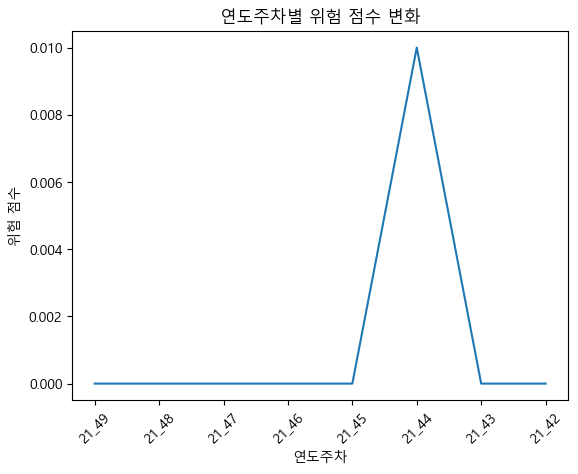

HS Code : 7326909000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=294.893, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-49.906, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-49.689, Time=0.09 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-60.423, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-57.436, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-61.090, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-22.373, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-60.411, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=

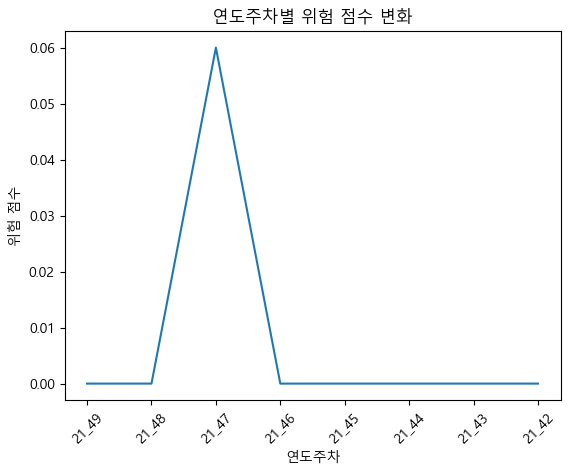

HS Code : 8708999000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=420.203, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=76.225, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=76.706, Time=0.06 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=75.588, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec

Best model:  ARIMA(1,0,2)(0,0,0)[0]          
Total fit time: 0.842 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
================

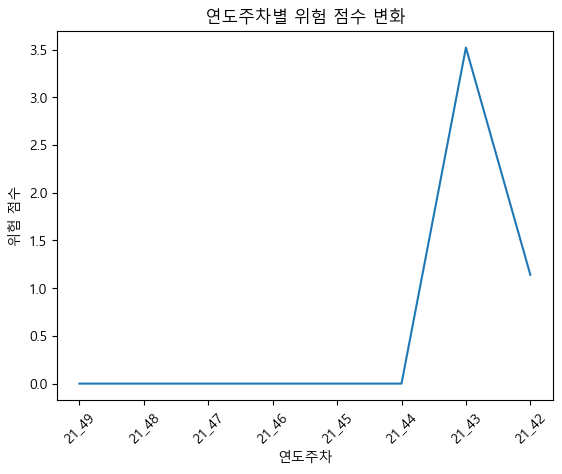

HS Code : 2106909099
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=477.953, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=177.147, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=172.032, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=175.489, Time=0.11 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=162.058, Time=0.15 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=184.780, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=171.719, Time=0.04 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=inf,

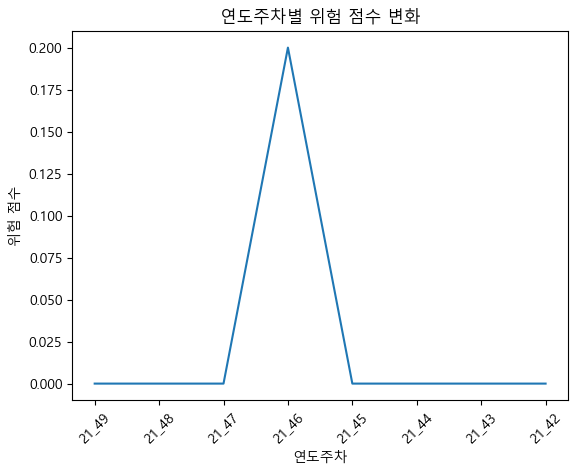

HS Code : 4911990000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=372.178, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=514.501, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=371.852, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=373.480, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=373.510, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=375.433, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=366.419, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=415.407, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=366.524, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=367.052, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=375.888, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=364.172, Time=0.10 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=368.156, Time=0.09 sec
 ARIMA(2,0,2)(0,0,0)[0

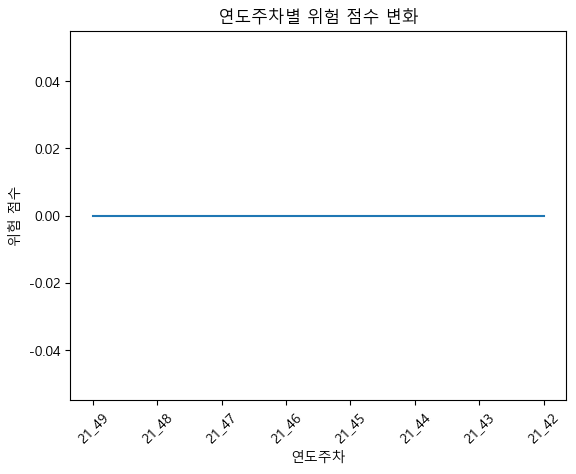

HS Code : 6403999000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=252.115, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=562.003, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=251.041, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=256.165, Time=0.03 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=250.773, Time=0.08 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.19 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.19 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf, Time=0.24 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=0.23 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=234.450, Time=0.17 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=inf, Tim

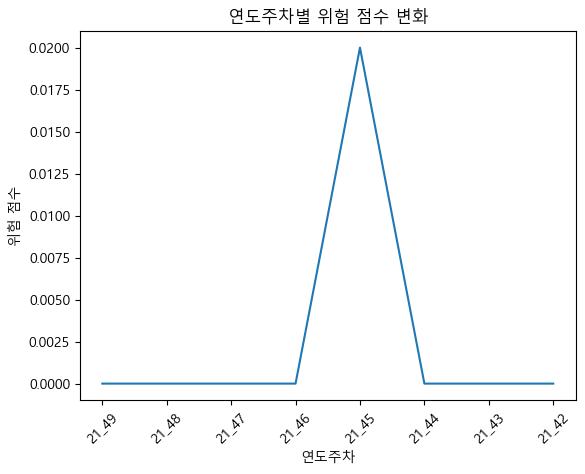

HS Code : 9031809099
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=644.260, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=428.473, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=430.471, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=416.554, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=417.314, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=418.178, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=453.055,

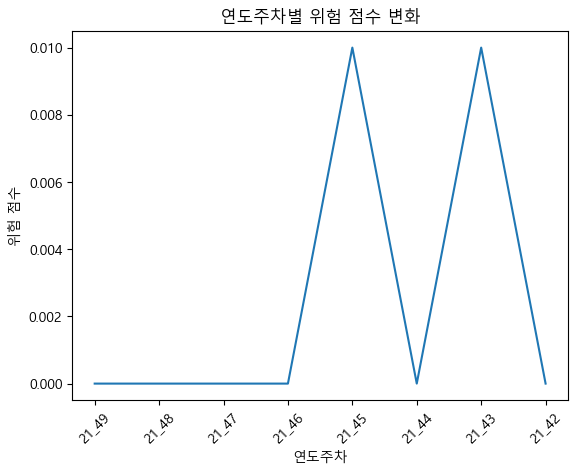

HS Code : 8542391000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=951.213, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=652.237, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=648.234, Time=0.08 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=649.196, Time=0.11 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=646.395, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=648.345, Time=0.11 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=638.138, Time=0.07 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=638.

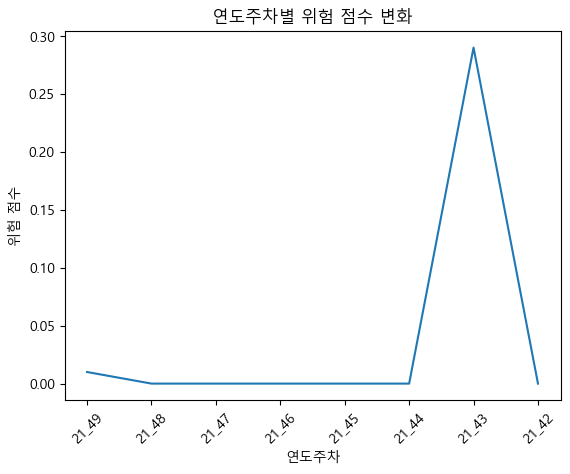

HS Code : 6109101000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=107.455, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=108.731, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=108.760, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=105.546, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=110.428, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.262 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=1174.710, Time=0.06 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=1194.338, Time=0.00 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=1190.523, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)

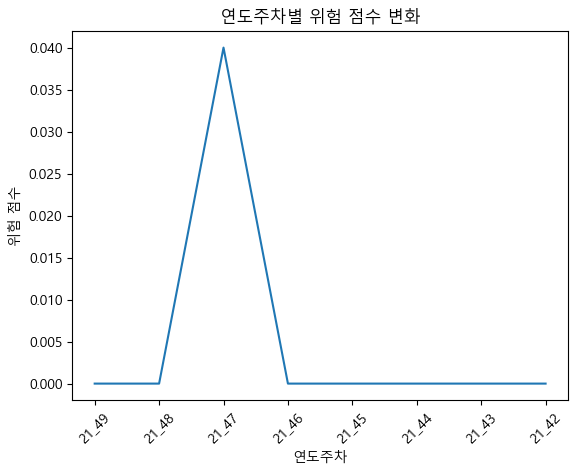

HS Code : 2934996000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=445.770, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=493.695, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=455.534, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=470.221, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=460.052, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=447.278, Time=0.08 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=447.587, Time=0.14 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=447.599, Time=0.12 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=447.368, Time=0.03 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=447.936, Time=0.06 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=454.334, Time=0.06 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.18 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=443.115, Time=0.13 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=444.331, Time=0.11 sec
 ARIMA(2,0,1)(0,0,0)[0

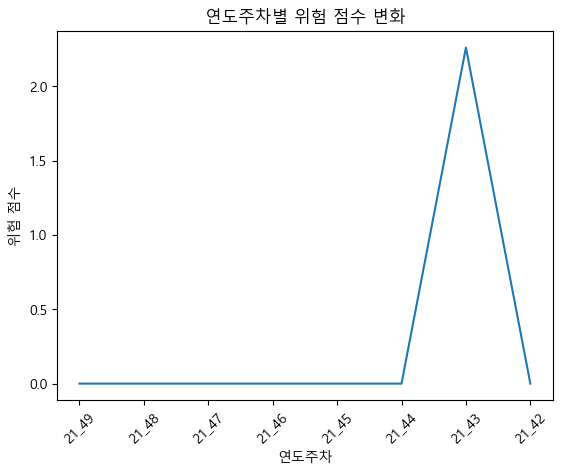

HS Code : 4016930000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=527.007, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=245.189, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=247.188, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=239.001, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=239.096, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=240.930, Time=0.13 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=240.411, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=286.

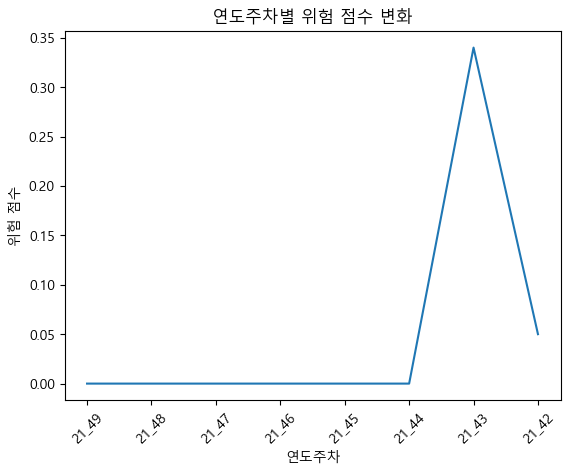

HS Code : 6110200000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=225.954, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=517.082, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=231.504, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=247.827, Time=0.04 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=244.942, Time=0.02 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=236.833, Time=0.06 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=227.197, Time=0.12 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=223.056, Time=0.08 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=229.779, Time=0.07 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : 

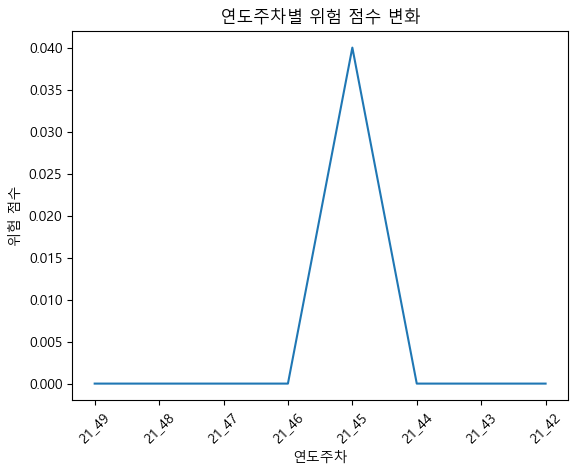

HS Code : 6211499000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=350.715, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=347.195, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=348.806, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=350.238, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=347.269, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=348.174, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=349.262, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=346.223, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=346.010, Time=0.01 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=347.996, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=348.006, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=346.995, Time=0.02 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=345.254, Time=0.06 sec
 ARIMA(4,1,1)(0,0,0)[0

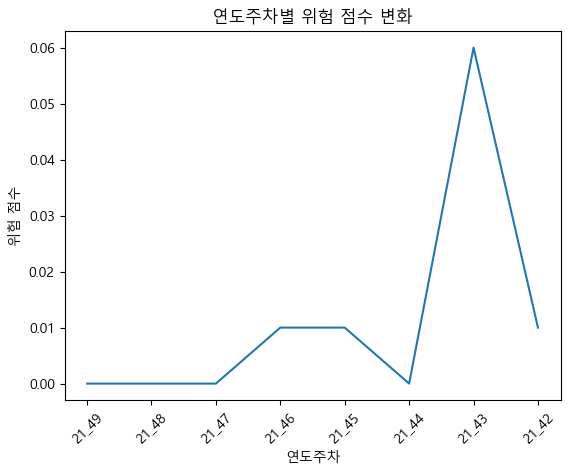

HS Code : 4202999000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=527.055, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=301.956, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=303.768, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=302.498, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=291.113, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=301.827, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=297.996, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=287.920, Time=0.15 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=288.236, Time=0.06 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : 

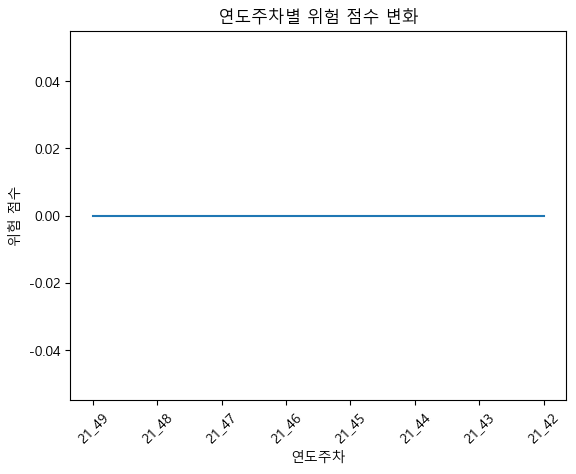

HS Code : 3304991000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=336.837, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=609.486, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=336.056, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=337.986, Time=0.04 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=324.702, Time=0.16 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=0.18 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.

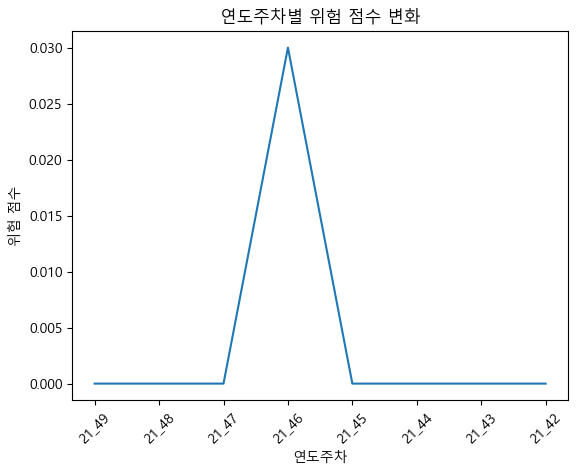

HS Code : 8544429090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=260.130, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=503.724, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=258.157, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=258.547, Time=0.02 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=260.011, Time=0.05 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=260.209, Time=0.02 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=244.513, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=253.241, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=248.899, Time=0.05 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : 

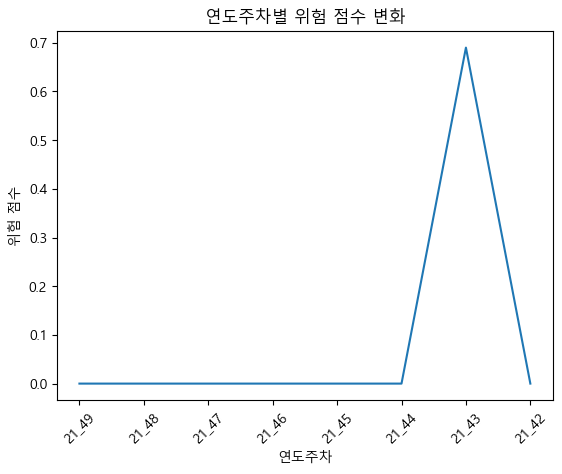

HS Code : 8481801090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=218.221, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=486.181, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=216.646, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=377.305, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=219.566, Time=0.04 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=215.845, Time=0.07 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=213.365, Time=0.18 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=208.801, Time=0.18 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=216.295, Time=0.07 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=212.323, Time=0.21 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(2,0,4)(0,0,0)[0]           

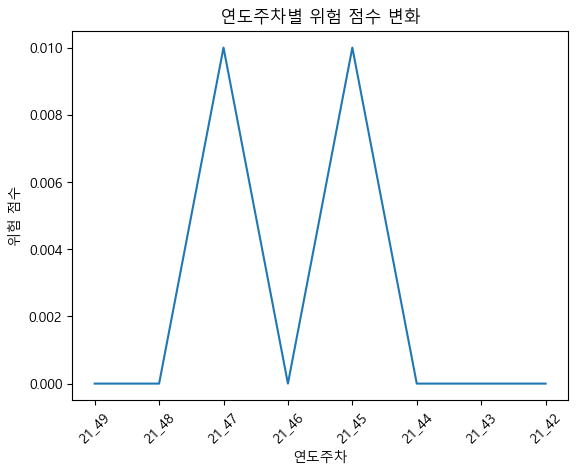

HS Code : 3304999000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=329.123, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=601.633, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=327.387, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=490.114, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=332.899, Time=0.04 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=332.444, Time=0.04 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=322.454, Time=0.16 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=329.

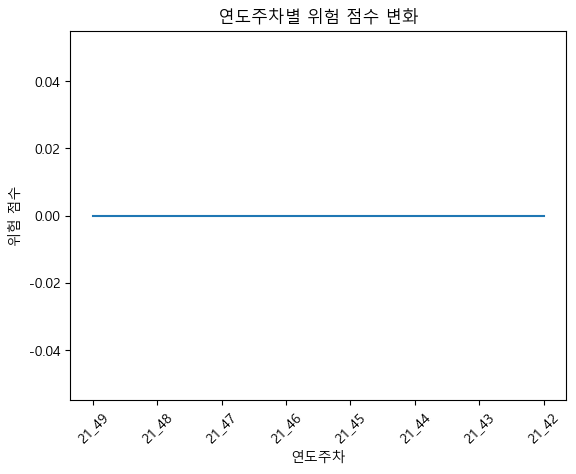

HS Code : 8543709090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=672.782, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=439.300, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=438.791, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=432.452, Time=0.11 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=428.684, Time=0.16 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=429.038, Tim

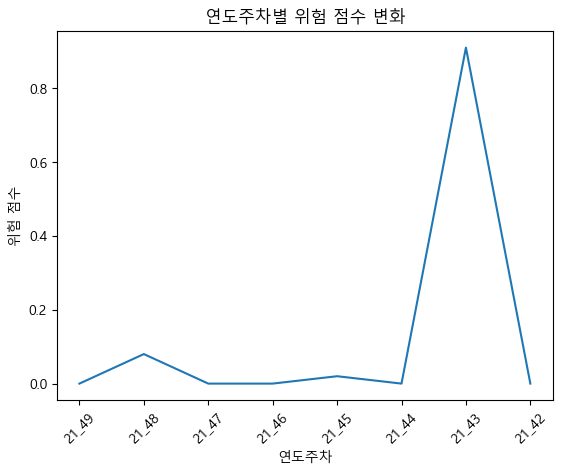

HS Code : 6404199000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=135.400, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=133.066, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=134.186, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=133.546, Time=0.00 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=134.152, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=134.660, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=131.125, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=132.177, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=132.699, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=132.281, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=inf, Time=0.06 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 0.462 seconds
==================

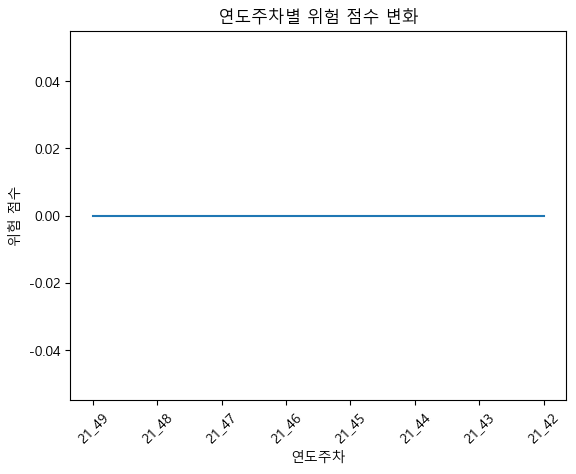

HS Code : 3004909900
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=334.289, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=560.197, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=335.974, Time=0.04 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=327.930, Time=0.08 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=331.843, Time=0.07 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=329.923, Time=0.11 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=333.049, Time=0.09 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=329.021, Time=0.07 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=318.839, Time=0.16 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : 

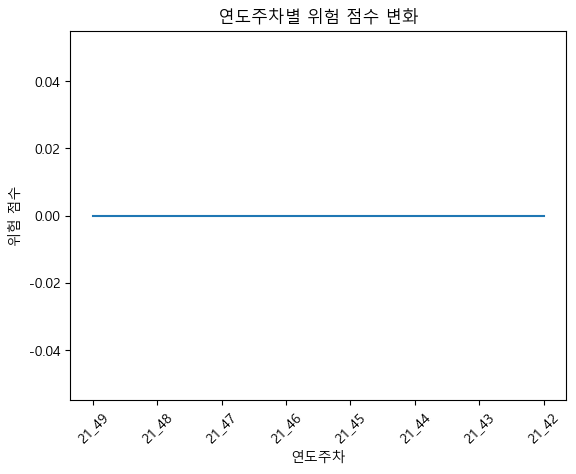

HS Code : 8542311000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1040.584, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=730.744, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=732.445, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=724.426, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=722.373, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=791.084, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=724.323, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf

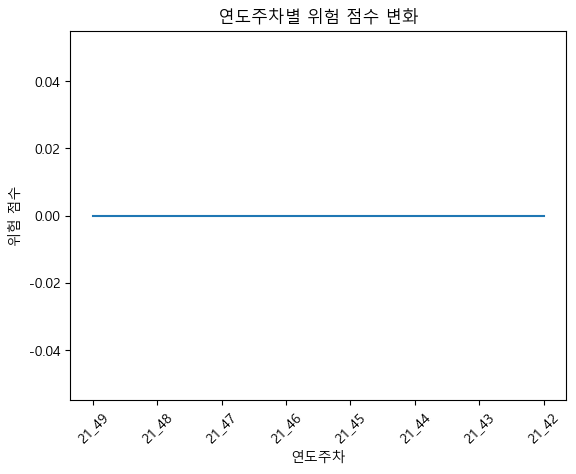

HS Code : 4901999000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=145.047, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=141.839, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=142.639, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=143.574, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=143.812, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=143.830, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=145.604, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=140.826, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=142.825, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=142.826, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=141.653, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=144.369, Time=0.03 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 0.323 seconds
==========

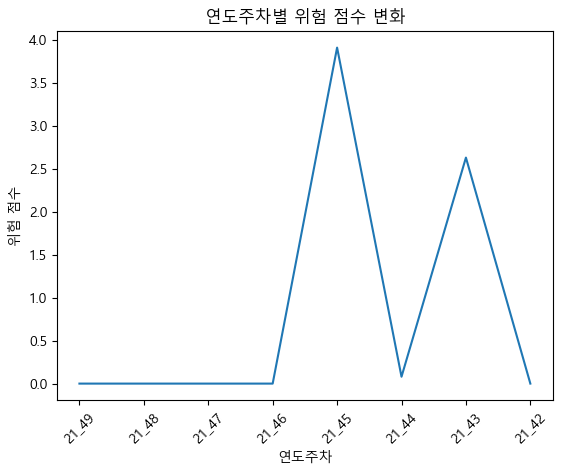

HS Code : 8473309090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=398.575, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=397.272, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=399.230, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=399.221, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=395.515, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.08 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.199 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1324.127, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]       

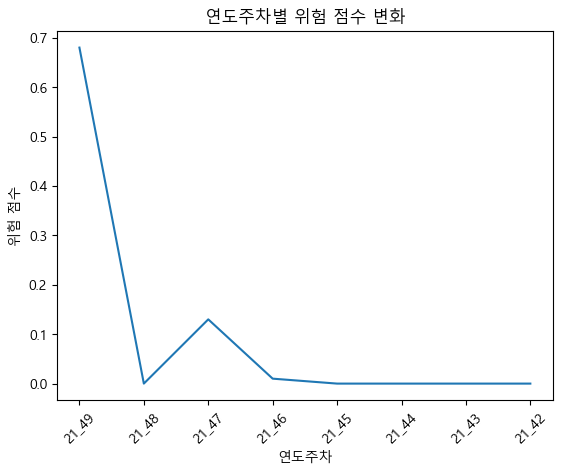

HS Code : 6307909000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=37.100, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=370.073, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=40.571, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=39.640, Time=0.03 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=39.328, Time=0.14 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=41.906, Time=0.17 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=17.375, Time=0.17 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=23.958, Time=0.07 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=19.543,

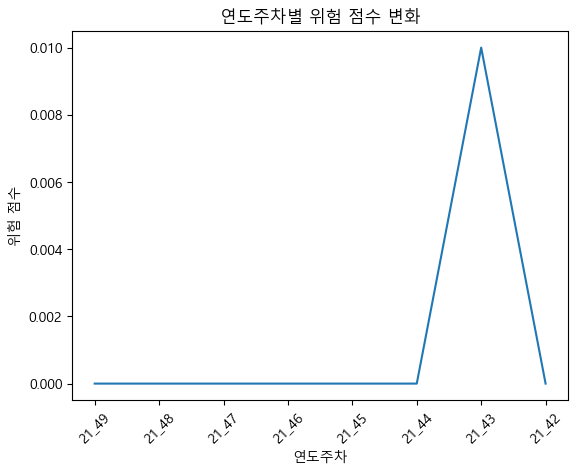

HS Code : 4202211090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=784.873, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=529.021, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=530.423, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=526.996, Time=0.06 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=527.902, Time=0.07 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=513.806, Time=0.09 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=527.121, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=518.799, Time=0.08 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=

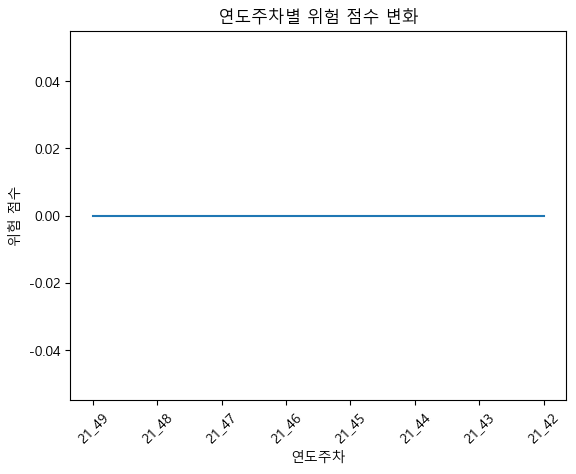

HS Code : 8536509090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=324.438, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=597.833, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=323.914, Time=0.06 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=324.312, Time=0.02 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=320.984, Time=0.07 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=0.18 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=303.680, Time=0.12 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=303.243,

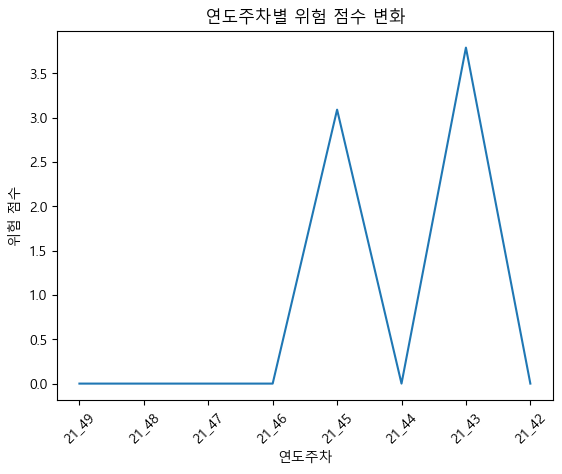

HS Code : 8538909000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=536.700, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=213.434, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=215.408, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=215.422, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=200.579, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=207.414, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=198.773, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=227.853, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=200.474, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : 

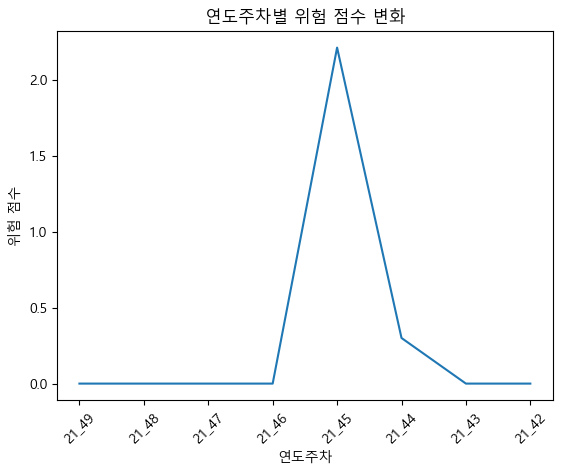

HS Code : 8479909090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=396.784, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=574.639, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=396.948, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=395.597, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=477.030, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=394.091, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=395.158, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=393.321, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=395.111, Time=0.04 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=396.433, Time=0.09 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=383.264, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=391.611, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=381.561, Time=0.03 sec
 ARIMA(4,0,0)(0,0,0)[0

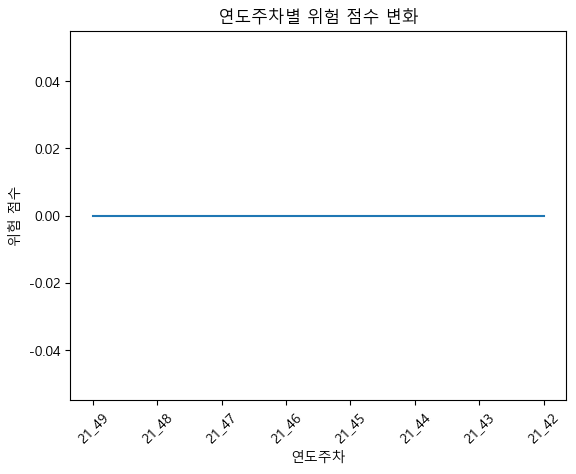

HS Code : 8504409099
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=562.973, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=268.181, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=268.132, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=450.659, Time=0.07 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=270.112, Time=0.08 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=266.054, Time=0.11 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=264.812, Time=0.18 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=267.158, Time=0.10 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=inf, Time=0.19 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=

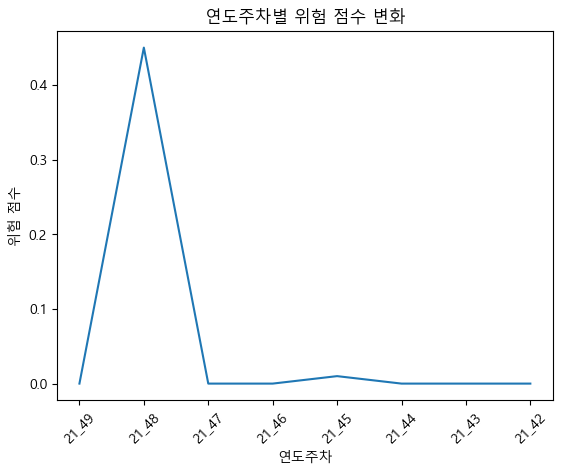

HS Code : 6110909000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=428.182, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=688.297, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=428.973, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=426.567, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=428.660, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=428.496, Time=0.05 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=426.497, Time=0.03 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=428.496, Time=0.05 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=416.585, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=417.272, Time=0.04 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept 

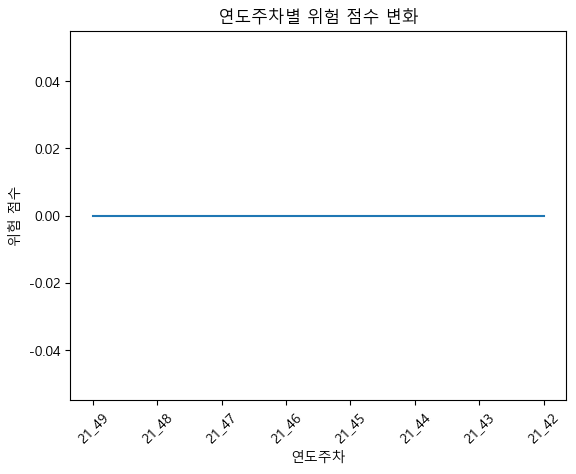

HS Code : 3923100000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=286.393, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-77.813, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-85.123, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-47.165, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-86.450, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-5.842, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-85.692, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-83.5

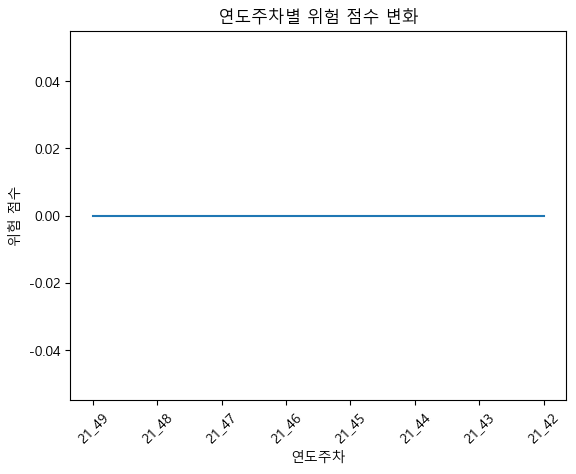

HS Code : 8544422090
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=445.867, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=84.988, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=90.145, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=85.190, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=75.028, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=80.098, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=73.971, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=104.199, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=74.924, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=76.

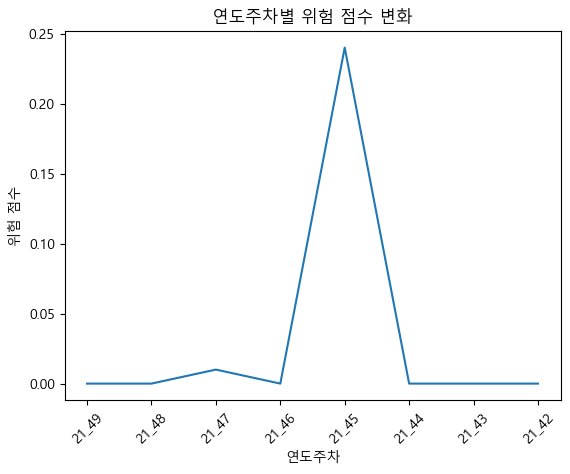

HS Code : 8537109000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=632.707, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=363.600, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=364.958, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=352.241, Time=0.09 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=357.706, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=351.022, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=368.279, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=351.702, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=

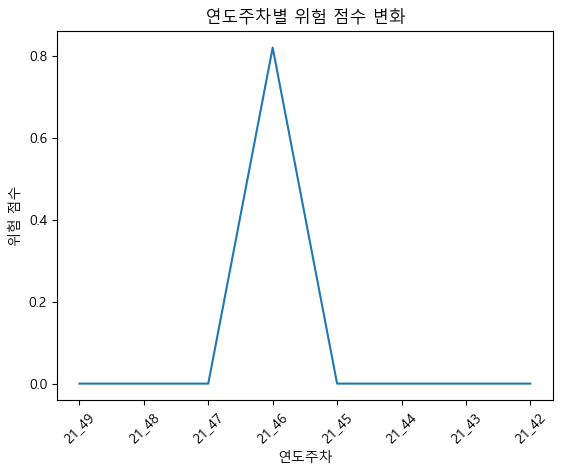

HS Code : 8536699000
21_49주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=515.163, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=243.832, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec

Best model:  ARIMA(1,0,1)(0,0,0)[0]          
Total fit time: 0.446 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to

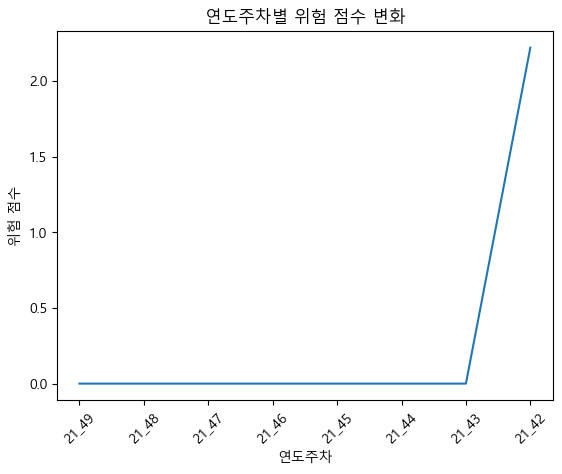

HS Code : 3102109000
21_14주차
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=-400.138, Time=0.10 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-395.166, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-399.350, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-401.940, Time=0.03 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-397.151, Time=0.01 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=-400.742, Time=0.06 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=-404.102, Time=0.05 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=-402.546, Time=0.06 sec
 ARIMA(0,2,3)(0,0,0)[0] intercept   : AIC=-404.920, Time=0.06 sec
 ARIMA(1,2,3)(0,0,0)[0] intercept   : AIC=-402.831, Time=0.10 sec
 ARIMA(0,2,4)(0,0,0)[0] intercept   : AIC=-398.482, Time=0.12 sec
 ARIMA(1,2,4)(0,0,0)[0] intercept   : AIC=-400.370, Time=0.16 sec
 ARIMA(0,2,3)(0,0,0)[0]             : AIC=-404.841, Time=0.04 sec

Best model:  ARIMA(0,2,3)(0,0,0)[0] intercept
Total fit time: 0.826 s

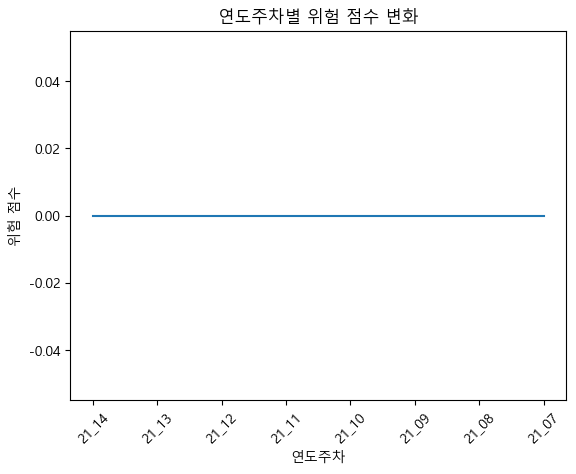

HS Code : 3707901010
19_04주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=715.734, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=467.624, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=468.782, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=464.299, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=443.234, Time=0.12 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=443.348, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=454.773, Time=0.04 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=inf,

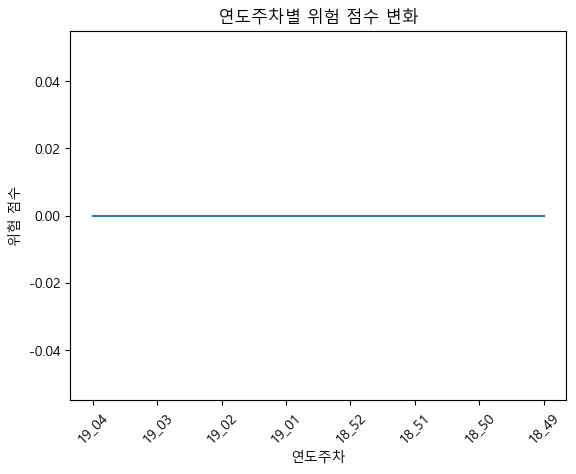

HS Code : 4407191000
20_41주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=169.039, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-176.375, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-174.857, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-186.735, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-176.683, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-185.617, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-184.684, Time=0.13 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-189.002, Time=0.12 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept  

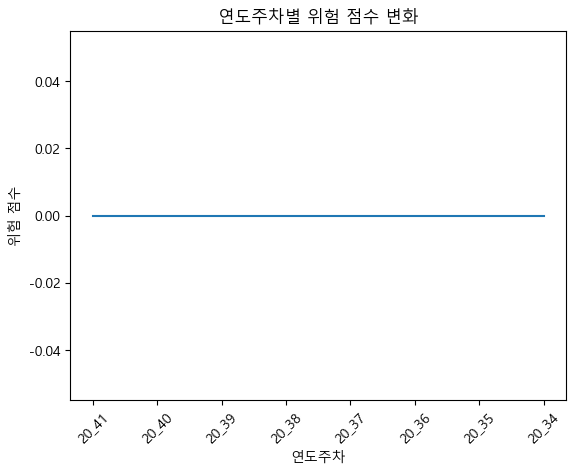

HS Code : 8111000000
21_19주차
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=-166.852, Time=0.11 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-154.473, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-169.547, Time=0.02 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-168.615, Time=0.04 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-156.449, Time=0.01 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=-167.644, Time=0.04 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=-167.742, Time=0.06 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=-170.324, Time=0.10 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=-168.707, Time=0.14 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=-166.835, Time=0.12 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=-166.353, Time=0.08 sec
 ARIMA(3,2,2)(0,0,0)[0] intercept   : AIC=-166.003, Time=0.24 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=-170.820, Time=0.13 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=-169.694, Time=0.04 sec
 ARI

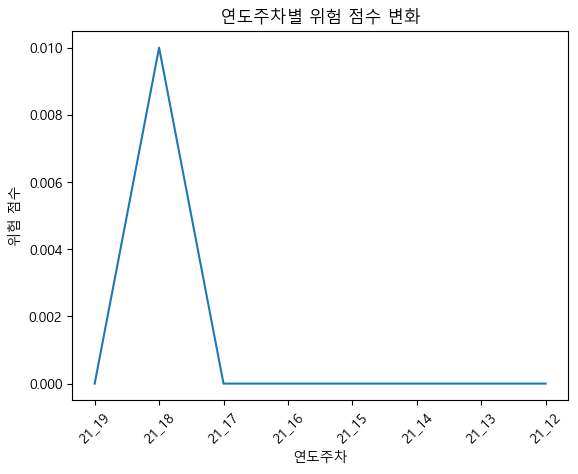

HS Code : 2701129010
21_25주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-376.241, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-382.124, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-381.960, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-382.677, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-383.457, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-381.767, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.157 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1885.917, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1884.353, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1885.371, Time=0.01 sec
 ARIMA(0,1

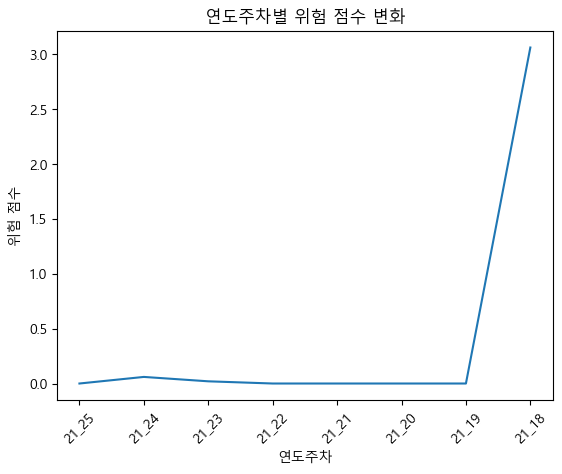

HS Code : 2804701000
21_25주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-72.326, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-70.475, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-68.665, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-68.668, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-72.327, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.288 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1396.603, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1222.055, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]  

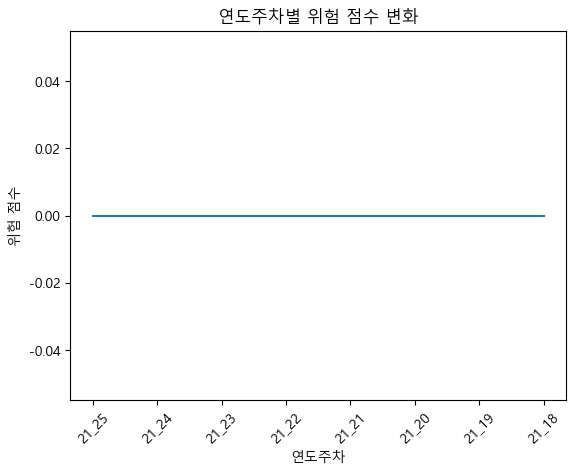

HS Code : 1511901000
21_29주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-229.005, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-235.939, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-235.045, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-235.083, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-227.076, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-233.085, Time=0.13 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.337 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1450.370, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1567.749, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1456.253, Time=0.00 sec
 ARIMA(0,0

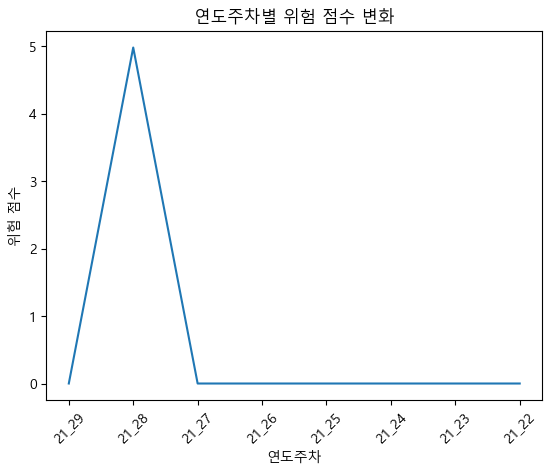

HS Code : 305531000
21_34주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=382.936, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=26.545, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=21.009, Time=0.06 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=14.114, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=12.284, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 se

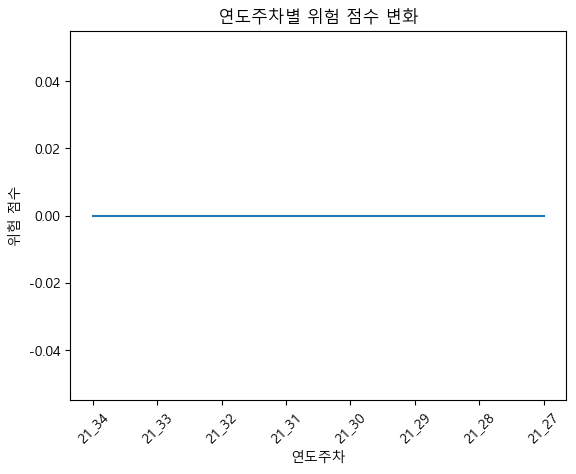

HS Code : 302140000
21_35주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-54.249, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9.660, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-40.573, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-37.273, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8.152, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-55.694, Time=0.07 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-51.579, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-57.687, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-51.753, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-53.736, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-59.687, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-39.044, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-42.526, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-53.751, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0]

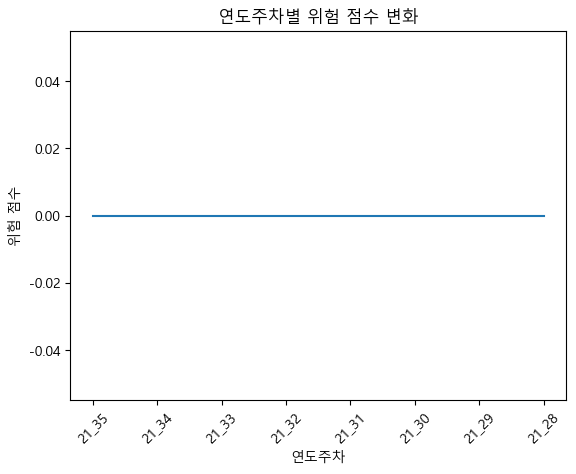

HS Code : 1003901000
21_34주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-329.682, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-328.923, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-328.078, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-328.683, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-330.891, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-324.985, Time=0.06 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.329 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1528.056, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1396.873, Time=0.00 sec
 ARIMA(0,0,1)(0

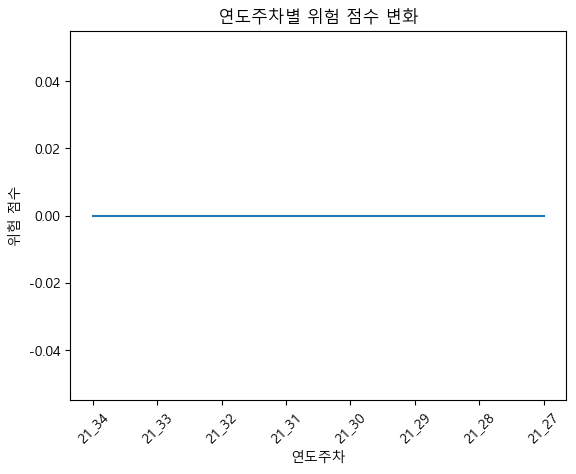

HS Code : 1003902000
21_34주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-280.853, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-287.776, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-286.598, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-286.708, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-289.772, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-290.028, Time=0.09 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-284.303, Time=0.14 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-284.453, Time=0.18 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-284.919, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-284.824, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-287.372, Time=0.06 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 0.962 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 

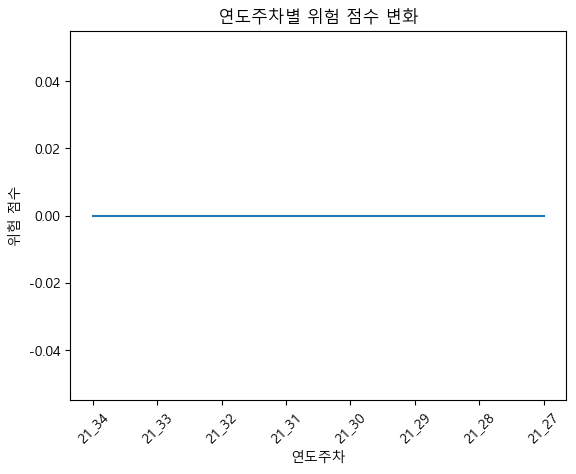

HS Code : 1104230000
21_34주차
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=190.972, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=173.115, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=162.527, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=164.148, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=164.207, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=158.779, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=182.070, Time=0.00 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=160.756, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=160.755, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=171.538, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0] intercept
Total fit time: 0.511 seconds
==================

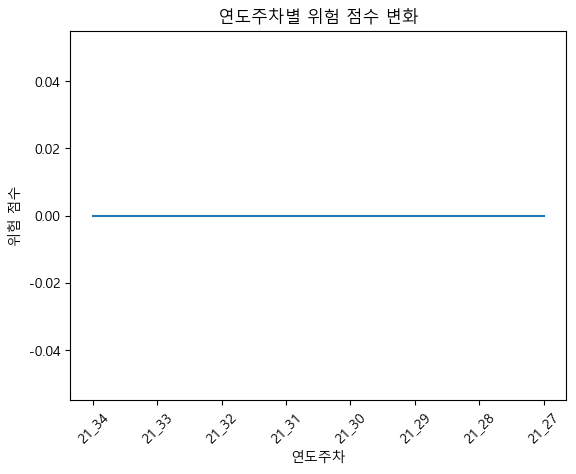

HS Code : 2710121000
21_34주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-203.273, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-206.832, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-205.206, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-205.196, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-206.696, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-203.204, Time=0.04 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.263 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1677.484, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1770.650, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1679.583, Time=0.01 sec
 ARIMA(0,0

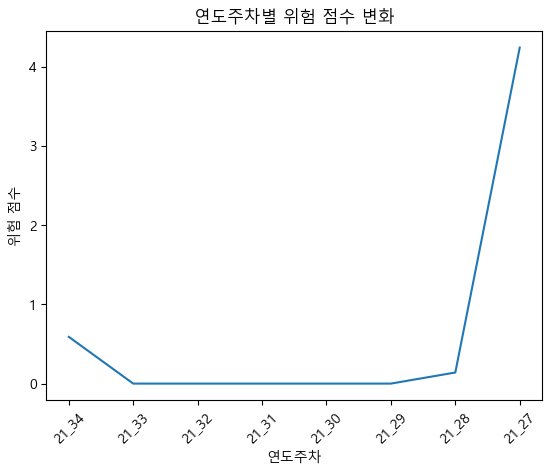

HS Code : 3104200000
21_34주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-274.954, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-279.355, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-279.758, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-280.298, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-280.556, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-278.835, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.258 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1713.875, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1719.567, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1717.197, Time=0.01 sec
 ARIMA(0,1

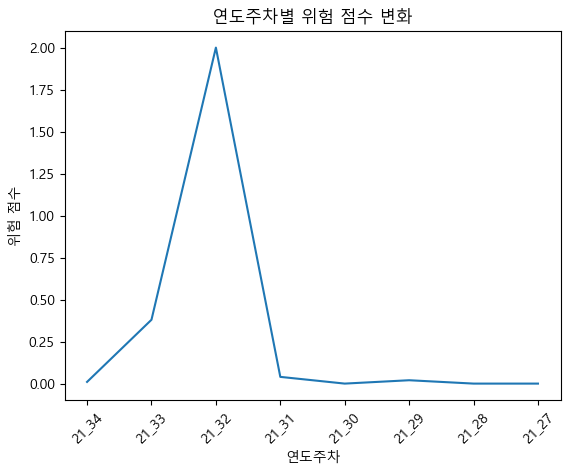

HS Code : 2905172000
21_43주차
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-116.817, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-116.616, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-116.322, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-116.176, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-114.838, Time=0.04 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.224 seconds
====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1145.802, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1306.436, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1144.346, Time=0.00 sec
 ARIMA(0,0,1)(0

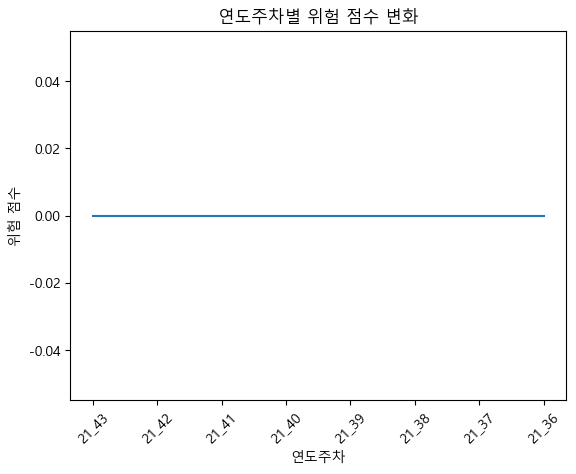

[np.float64(0.01), np.float64(0.06), np.float64(3.52), np.float64(0.2), 0, np.float64(0.02), np.float64(0.01), np.float64(0.29), np.float64(0.04), np.float64(2.26), np.float64(0.34), np.float64(0.04), np.float64(0.06), 0, np.float64(0.03), np.float64(0.69), np.float64(0.01), 0, np.float64(0.91), 0, 0, 0, np.float64(3.91), np.float64(0.68), np.float64(0.01), 0, np.float64(3.79), np.float64(2.21), 0, np.float64(0.45), 0, 0, np.float64(0.24), np.float64(0.82), np.float64(2.22), 0, 0, 0, np.float64(0.01), np.float64(3.06), 0, np.float64(4.98), 0, 0, 0, 0, 0, np.float64(4.24), np.float64(2.0), 0]
[47, 44, 48, 45, 0, 46, 46, 48, 44, 48, 48, 46, 48, 0, 45, 48, 44, 0, 48, 0, 0, 0, 46, 42, 48, 0, 48, 46, 0, 43, 0, 0, 46, 45, 49, 0, 0, 0, 73, 73, 0, 63, 0, 0, 0, 0, 0, 64, 59, 0]


In [3]:
리스트 = pd.read_excel('c:\python\list(m).xlsx')
추출용 = 리스트.iloc[:,0].tolist()
리스트 = pd.read_excel('c:\python\list(m1).xlsx')
b = 리스트.iloc[:,0].tolist()

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        res_resid = df_price_4w['단가'].iloc[p_eriod-l:-l]
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]
        model = pm.auto_arima(res_resid[:-n_test], seasonal=False, trace=True)
        model_fit = model.fit(res_resid[:-n_test])
        p, d, q = model.order

        print('====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============')
        model1 = ARIMA(res_resid[:-n_test], order=(p,d,q))
        model_fit1 = model1.fit()
        forecast1 = model_fit1.get_forecast(steps=1)
              
        print('======================= 여기부터 GARCH 모델링 =================================')
        arima_residuals = model_fit1.resid
        garch = arch.arch_model(arima_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        # Use GARCH to predict the residual
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        
        stand_quant = (test.iloc[0] - forecast1.predicted_mean.iloc[0])/ garch_std
        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)

      #=================== 신고중량 ======================
        res_resid = df_price_4w['신고중량'].iloc[p_eriod-l:-l]
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]

        model = pm.auto_arima(res_resid[:-n_test], seasonal=False, trace=True)
        model_fit = model.fit(res_resid[:-n_test])
        p, d, q = model.order

        print('====================== Statemodels를 활용한 ARIMA 예측 및 confidence level 범위 구하기 ==============')
        model1 = ARIMA(res_resid[:-n_test], order=(p,d,q))
        model_fit1 = model1.fit()
        forecast1 = model_fit1.get_forecast(steps=1)

        print('======================= 여기부터 GARCH 모델링 =================================')
        arima_residuals = model_fit1.resid
        garch = arch.arch_model(arima_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        stand_quant = (test.iloc[0] - forecast1.predicted_mean.iloc[0])/ garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y
      
    if(z[j]<1.85):
        o[j] = 1
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)

# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:49, 'Model2(1)'] = o
collect.loc[50, 'Model2(1)'] = np.sum(o)
collect.loc[:49, 'Model2(2)'] = z
collect.loc[50, 'Model2(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[15:65, 'y_scores[3]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[15:65, 'y_scores[3]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[15:65, 'y_scores[3]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)